In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive

/content/drive/MyDrive


In [ ]:
# !pip install catboost
# !pip install prophet

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
import json

# Function to safely load JSON
def load_json(file_path):
    with open(file_path, 'r') as f:
        return json.load(f)

# Load raw data
sales_data = load_json('cleaned_sales.json')
inventory_data = load_json('cleaned_inventory.json')
recipes_data = load_json('recipes.json')
users_data = load_json('cleaned_users.json')

In [ ]:
# Convert to DataFrames
sales_df = pd.DataFrame(sales_data)
inventory_df = pd.DataFrame(inventory_data)
users_df = pd.DataFrame(users_data)
recipes_df = pd.DataFrame(recipes_data)

In [ ]:
display(sales_df.head())

,id,Date,day_of_week,is_holiday,weather,temperature,customer_id,items_purchased,total_bill,payment_method
0,1,22-01-2023,Sunday,1,Sunny,32.5,CUST1428,"{""Pasta Red Sauce"": 2, ""Momos Veg Fried"": 1, ""...",720,UPI
1,2,22-01-2023,Sunday,1,Sunny,32.5,CUST1150,"{""Plain Rice"": 1, ""Pepsi"": 1, ""Cold Coffee"": 1...",270,Cash
2,3,22-01-2023,Sunday,1,Sunny,32.5,CUST1301,"{""Pepsi"": 1}",40,Cash
3,4,22-01-2023,Sunday,1,Sunny,32.5,CUST1351,"{""Pizza Chicken"": 1, ""Vada Pav"": 1, ""Coffee"": 1}",280,Cash
4,5,22-01-2023,Sunday,1,Sunny,32.5,CUST1254,"{""Pizza Veg"": 1, ""Tea"": 1, ""Paneer Biryani"": 1}",485,UPI


In [ ]:
# Clean
sales_df.drop(columns=['_id'], errors='ignore', inplace=True)
inventory_df.drop(columns=['_id'], errors='ignore', inplace=True)
recipes_df.drop(columns=['_id'], errors='ignore', inplace=True)

sales_df['Date'] = pd.to_datetime(sales_df['Date'])
inventory_df['Date'] = pd.to_datetime(inventory_df['Date'])

/tmp/ipykernel_36806/3952233082.py:6: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  sales_df['Date'] = pd.to_datetime(sales_df['Date'])
/tmp/ipykernel_36806/3952233082.py:7: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  inventory_df['Date'] = pd.to_datetime(inventory_df['Date'])


In [ ]:
# Convert string to dictionary
import ast
sales_df['items_purchased'] = sales_df['items_purchased'].apply(ast.literal_eval)

rows = []

for _, row in sales_df.iterrows():
    for item, qty in row['items_purchased'].items():
        rows.append({
            'Date': row['Date'],
            'Item': item.strip().lower(),
            'Quantity': qty
        })

items_df = pd.DataFrame(rows)

In [ ]:
daily_sales = sales_df.groupby('Date')['total_bill'].sum().reset_index()

In [ ]:
extra = sales_df.groupby('Date').agg({
    'day_of_week': 'first',
    'is_holiday': 'max',
    'weather': 'first',
    'temperature': 'first'
}).reset_index()

daily_sales = daily_sales.merge(extra, on='Date')

In [ ]:
daily_sales

,Date,total_bill,day_of_week,is_holiday,weather,temperature
0,2023-01-22,88420,Sunday,1,Sunny,32.5
1,2023-01-23,39600,Monday,0,Sunny,32.5
2,2023-01-24,54345,Tuesday,0,Sunny,27.5
3,2023-01-25,49165,Wednesday,0,Sunny,32.5
4,2023-01-26,57420,Thursday,0,Cloudy,27.5
...,...,...,...,...,...,...
1065,2026-03-27,37280,Friday,0,Cloudy,32.5
1066,2026-03-28,52200,Saturday,0,Sunny,32.5
1067,2026-03-29,54720,Sunday,1,Sunny,22.5
1068,2026-03-30,32880,Monday,0,Cloudy,22.5


In [ ]:
# Time features
daily_sales['day'] = daily_sales['Date'].dt.day
daily_sales['month'] = daily_sales['Date'].dt.month
daily_sales['day_of_week_num'] = daily_sales['Date'].dt.weekday

# Lag features
daily_sales['lag_1'] = daily_sales['total_bill'].shift(1)
daily_sales['lag_2'] = daily_sales['total_bill'].shift(2)
daily_sales['lag_7'] = daily_sales['total_bill'].shift(7)

# Rolling (NO leakage)
daily_sales['rolling_mean_3'] = daily_sales['total_bill'].shift(1).rolling(3).mean()
daily_sales['rolling_mean_7'] = daily_sales['total_bill'].shift(1).rolling(7).mean()

# Weekend
daily_sales['is_weekend'] = daily_sales['day_of_week_num'].apply(lambda x: 1 if x >= 5 else 0)

# Drop NaN
daily_sales.dropna(inplace=True)

In [ ]:
daily_sales = pd.get_dummies(daily_sales, columns=[
    'day_of_week',
    'weather',
    'temperature'
], drop_first=True)

In [ ]:
X = daily_sales.drop(['total_bill', 'Date'], axis=1)
y = daily_sales['total_bill']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [ ]:
# 1. XGBoost
model_xgb =XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model_xgb.fit(X_train, y_train)
xgb_preds = model_xgb.predict(X_test)

# 2. CatBoost
model_cat = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_state=42)
model_cat.fit(X_train, y_train)
cat_preds = model_cat.predict(X_test)

# 3. LightGBM
model_lgbm = LGBMRegressor(n_estimators=500, learning_rate=0.05, verbose=-1, random_state=42)
model_lgbm.fit(X_train, y_train)
lgbm_preds = model_lgbm.predict(X_test)

# 4. Random Forest
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
rf_preds = model_rf.predict(X_test)

# 5. SARIMAX (Note: This uses the 'daily_sales' series directly)
# (1,1,1) are standard starting parameters
model_sarima = SARIMAX(y_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
results_sarima = model_sarima.fit(disp=False)
sarima_preds = results_sarima.get_forecast(steps=len(y_test)).predicted_mean

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index

In [ ]:
def get_metrics(y_true, y_pred, name):
    return {
        'Model': name,
        'MAE': round(mean_absolute_error(y_true, y_pred), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        'R2 Score': round(r2_score(y_true, y_pred), 4),
        'MAPE (%)': round(np.mean(np.abs((y_true - y_pred) / y_true)) * 100, 2)
    }

results = [
    get_metrics(y_test, xgb_preds, "XGBoost"),
    get_metrics(y_test, cat_preds, "CatBoost"),
    get_metrics(y_test, lgbm_preds, "LightGBM"),
    get_metrics(y_test, rf_preds, "Random Forest"),
    get_metrics(y_test, sarima_preds, "SARIMAX")
]

performance_matrix = pd.DataFrame(results).sort_values(by='MAE')

print("=== FINAL MODEL PERFORMANCE MATRIX ===")
print(performance_matrix.to_string(index=False))

=== FINAL MODEL PERFORMANCE MATRIX ===
        Model      MAE     RMSE  R2 Score  MAPE (%)
      XGBoost  5258.76  6533.44    0.7920     10.01
     CatBoost  5395.25  6766.40    0.7769     10.34
Random Forest  5614.24  6857.02    0.7709     10.84
     LightGBM  5786.91  7178.26    0.7489     10.97
      SARIMAX 11851.41 14364.68   -0.0054     23.47


In [ ]:
best_model_info = performance_matrix.loc[performance_matrix['MAE'].idxmin()]
best_model_name = best_model_info['Model']

print(f"The best performing model based on MAE is: {best_model_name}")
print("Performance details for the best model:")
print(best_model_info.to_string(index=False))

The best performing model based on MAE is: XGBoost
Performance details for the best model:
 XGBoost
 5258.76
 6533.44
   0.792
   10.01


In [ ]:
# Create a dictionary to map model names to their objects
model_registry = {
    "XGBoost": model_xgb,
    "CatBoost": model_cat,
    "LightGBM": model_lgbm,
    "Random Forest": model_rf,
    "SARIMAX": results_sarima
}

# Select the best model object based on the best_model_name
model_to_use = model_registry.get(best_model_name)

if model_to_use is None:
    raise ValueError(f"Model '{best_model_name}' not found in registry. Please ensure it's trained and included.")

In [ ]:
last_date = daily_sales['Date'].max()

future_dates = pd.date_range(start=last_date, periods=8)[1:]
future_df = pd.DataFrame({'Date': future_dates})

future_df['day'] = future_df['Date'].dt.day
future_df['month'] = future_df['Date'].dt.month
future_df['day_of_week_num'] = future_df['Date'].dt.weekday

last = daily_sales.iloc[-1]

future_df['lag_1'] = last['total_bill']
future_df['lag_2'] = last['lag_1']
future_df['lag_7'] = last['lag_7']
future_df['rolling_mean_3'] = last['rolling_mean_3']
future_df['rolling_mean_7'] = last['rolling_mean_7']
future_df['is_weekend'] = future_df['day_of_week_num'].apply(lambda x: 1 if x >= 5 else 0)

# Match columns
future_df = pd.get_dummies(future_df)
future_df = future_df.reindex(columns=X.columns, fill_value=0)

future_sales = model_to_use.predict(future_df)

future_df['Predicted_Sales'] = future_sales

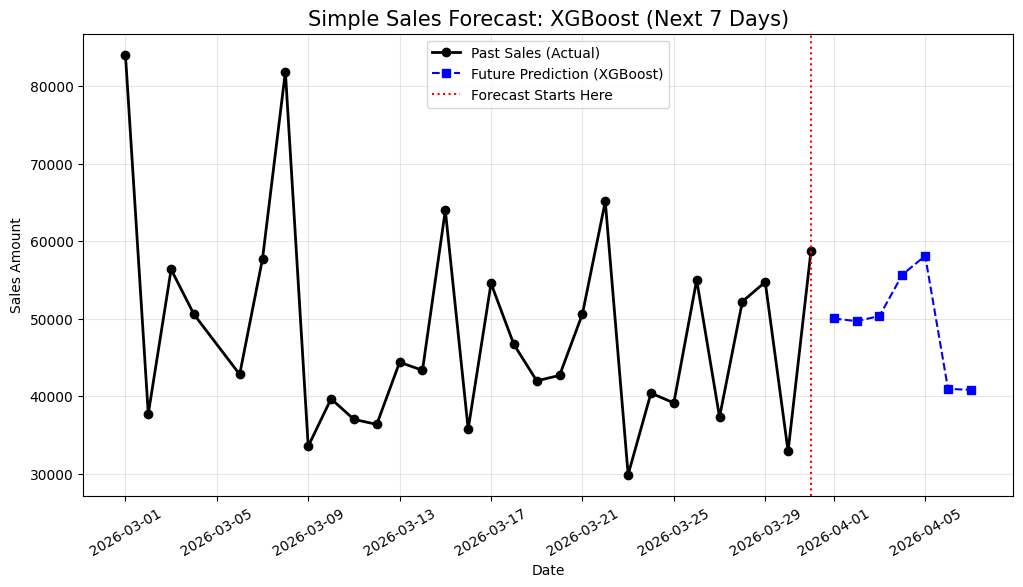

In [ ]:
import matplotlib.pyplot as plt

# Use the 7-day forecast results generated by the previous cell
best_preds = future_df['Predicted_Sales']
# Re-create future_dates for plotting purposes as it was removed from future_df
last_date_for_plotting = daily_sales['Date'].max()
forecast_dates_7_day = pd.date_range(start=last_date_for_plotting, periods=8)[1:]
model_name = best_model_name # Explicitly set model name as XGBoost was chosen as best

plt.figure(figsize=(12, 6))

# 1. Plot Historical Context (Last 30 days of actual sales from daily_sales)
plt.plot(daily_sales['Date'].tail(30), daily_sales['total_bill'].tail(30),
         label='Past Sales (Actual)', color='black', marker='o', linewidth=2)

# 2. Plot The Forecast (the 7 predicted values for the 7 forecast dates)
plt.plot(forecast_dates_7_day, best_preds,
         label=f'Future Prediction ({model_name})', color='blue', linestyle='--', marker='s')

# Add a vertical line to indicate where the forecast starts
plt.axvline(x=daily_sales['Date'].max(), color='red', linestyle=':', label='Forecast Starts Here')

plt.title(f"Simple Sales Forecast: {model_name} (Next 7 Days)", fontsize=15)
plt.ylabel("Sales Amount")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.show()

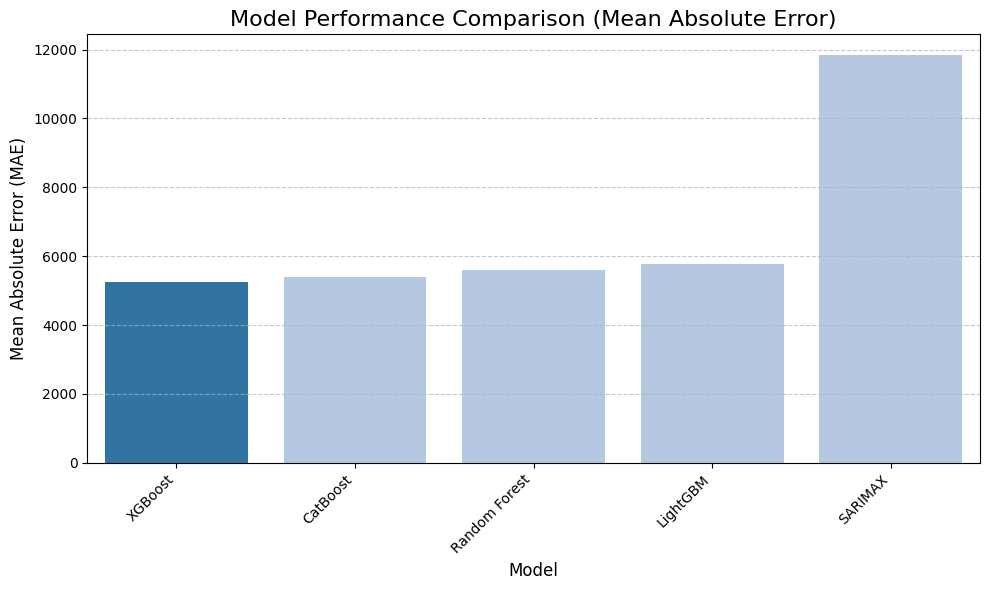

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the performance matrix by MAE for better visualization
performance_matrix_sorted = performance_matrix.sort_values(by='MAE', ascending=True)

# Define colors: highlight the best model
colors = ['#1f77b4' if model == best_model_name else '#aec7e8' for model in performance_matrix_sorted['Model']]

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='MAE', hue='Model', data=performance_matrix_sorted, palette=colors, legend=False)
plt.title('Model Performance Comparison (Mean Absolute Error)', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Mean Absolute Error (MAE)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This bar chart visually represents the Mean Absolute Error (MAE) for each of the trained models. A lower MAE indicates a more accurate model. As observed, XGBoost exhibits the lowest MAE, reinforcing its position as the best-performing model among those evaluated.

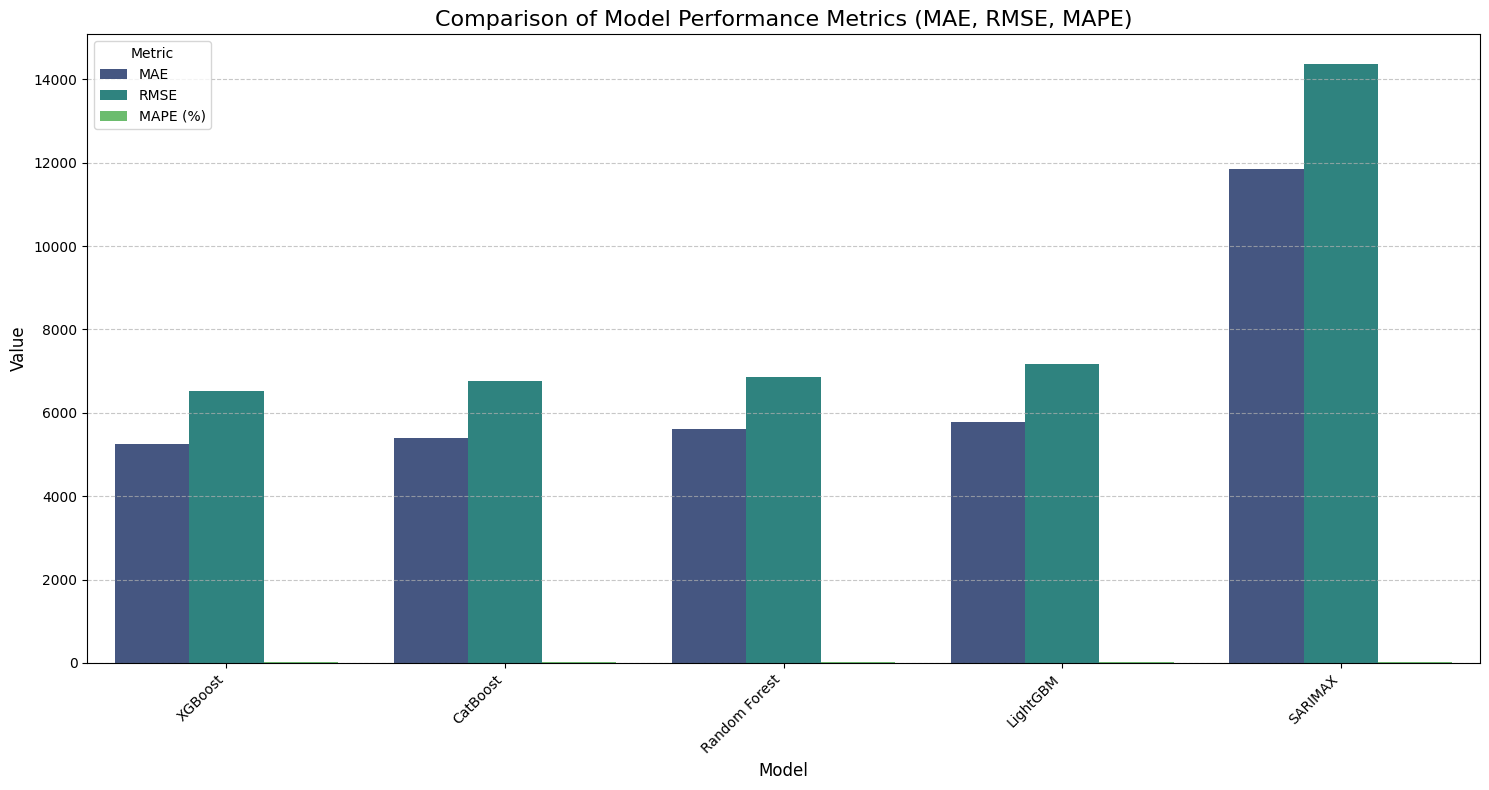

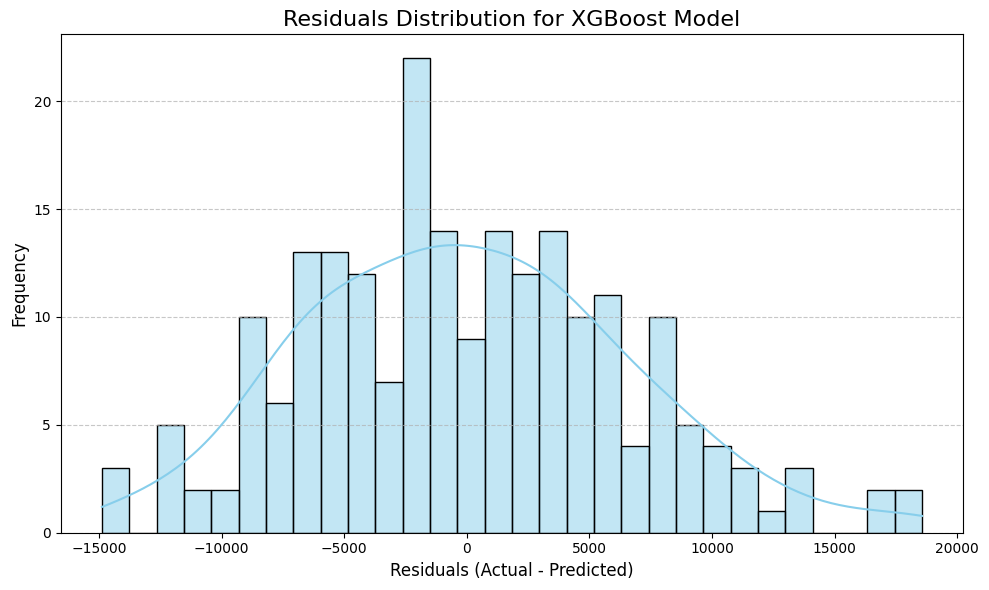

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. Metric Comparison Grouped Bar Chart ---

# Melt the performance_matrix to a long format for easier plotting
performance_melted = performance_matrix.melt(
    id_vars=['Model'],
    value_vars=['MAE', 'RMSE', 'MAPE (%)'],
    var_name='Metric',
    value_name='Value'
)

plt.figure(figsize=(15, 8))
sns.barplot(x='Model', y='Value', hue='Metric', data=performance_melted, palette='viridis')
plt.title('Comparison of Model Performance Metrics (MAE, RMSE, MAPE)', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n")

# --- 2. Error Distribution (Residual Plot) for XGBoost ---

# Calculate residuals for the best model (XGBoost)
residuals_xgb = y_test - xgb_preds

plt.figure(figsize=(10, 6))
sns.histplot(residuals_xgb, kde=True, color='skyblue', bins=30)
plt.title(f'Residuals Distribution for {best_model_name} Model', fontsize=16)
plt.xlabel('Residuals (Actual - Predicted)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

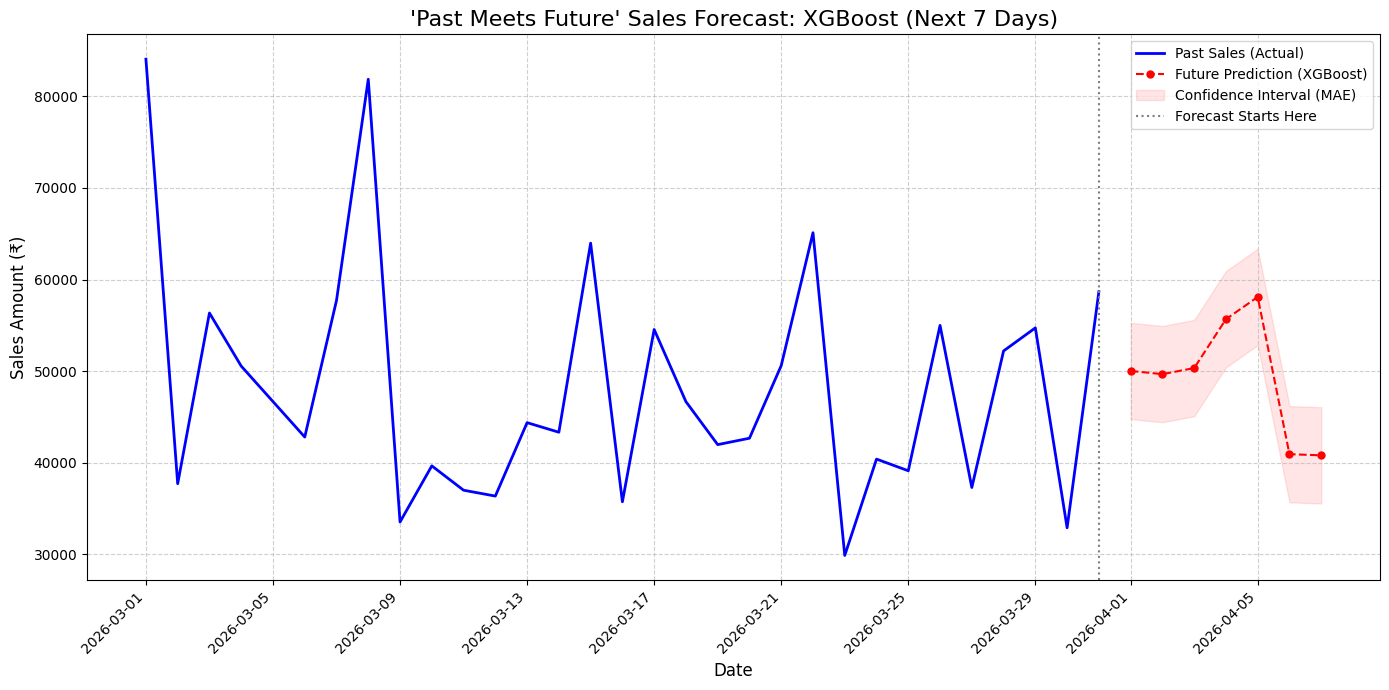

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the MAE for the confidence interval
mae_value = best_model_info['MAE']

plt.figure(figsize=(14, 7))

# --- Historical Data (Last 30 days) ---
historical_days = 30
plot_historical_df = daily_sales.tail(historical_days).copy()
plt.plot(plot_historical_df['Date'], plot_historical_df['total_bill'],
         label='Past Sales (Actual)', color='blue', linewidth=2)

# --- Forecast Data (Next 7 days) ---
# Recreate future_dates for plotting purposes as it was removed from future_df
last_date_for_plotting = daily_sales['Date'].max()
forecast_dates_7_day = pd.date_range(start=last_date_for_plotting, periods=8)[1:]

plt.plot(forecast_dates_7_day, future_df['Predicted_Sales'],
         label=f'Future Prediction ({best_model_name})',
         color='red', linestyle='--', marker='o', markersize=5)

# --- Confidence Interval ---
upper_bound = future_df['Predicted_Sales'] + mae_value
lower_bound = future_df['Predicted_Sales'] - mae_value
plt.fill_between(forecast_dates_7_day, lower_bound, upper_bound, color='red', alpha=0.1,
                 label='Confidence Interval (MAE)')

# Add a vertical line to indicate where the forecast starts
plt.axvline(x=daily_sales['Date'].max(), color='grey', linestyle=':', label='Forecast Starts Here')

plt.title(f"Sales Forecast: {best_model_name} (Next 7 Days)", fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales Amount (₹)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

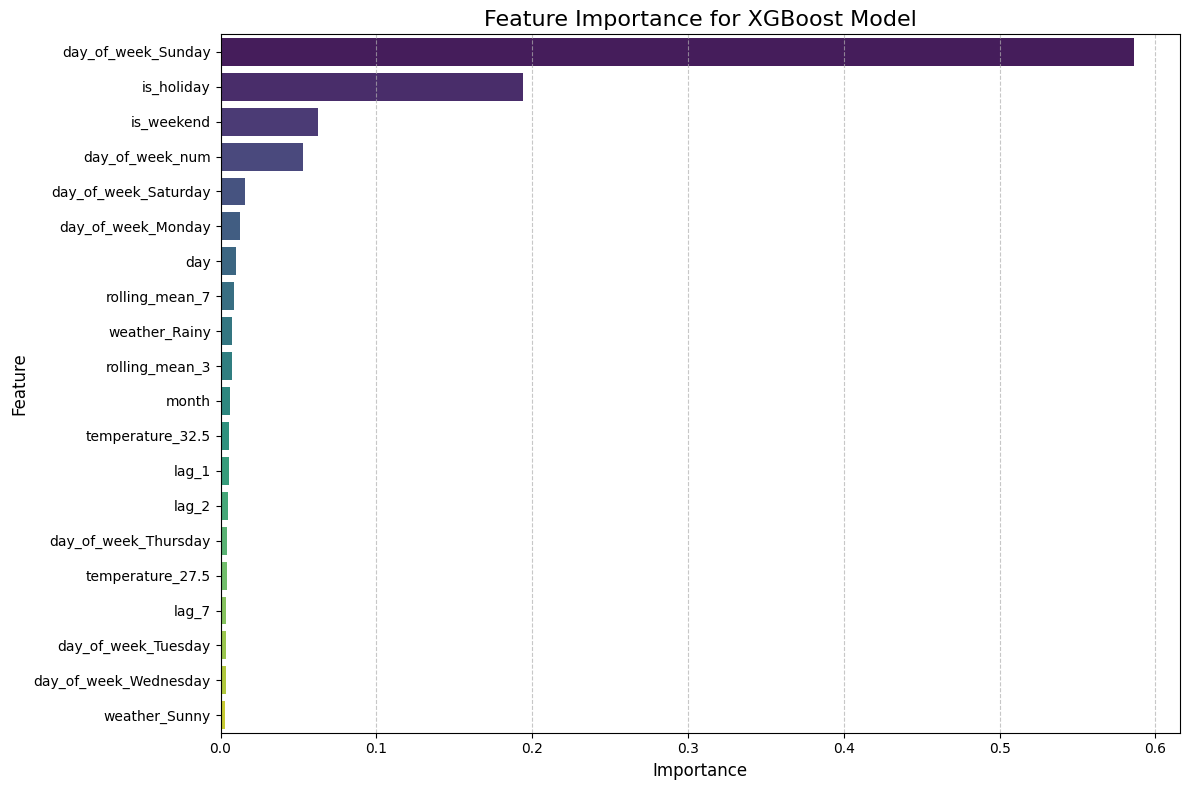

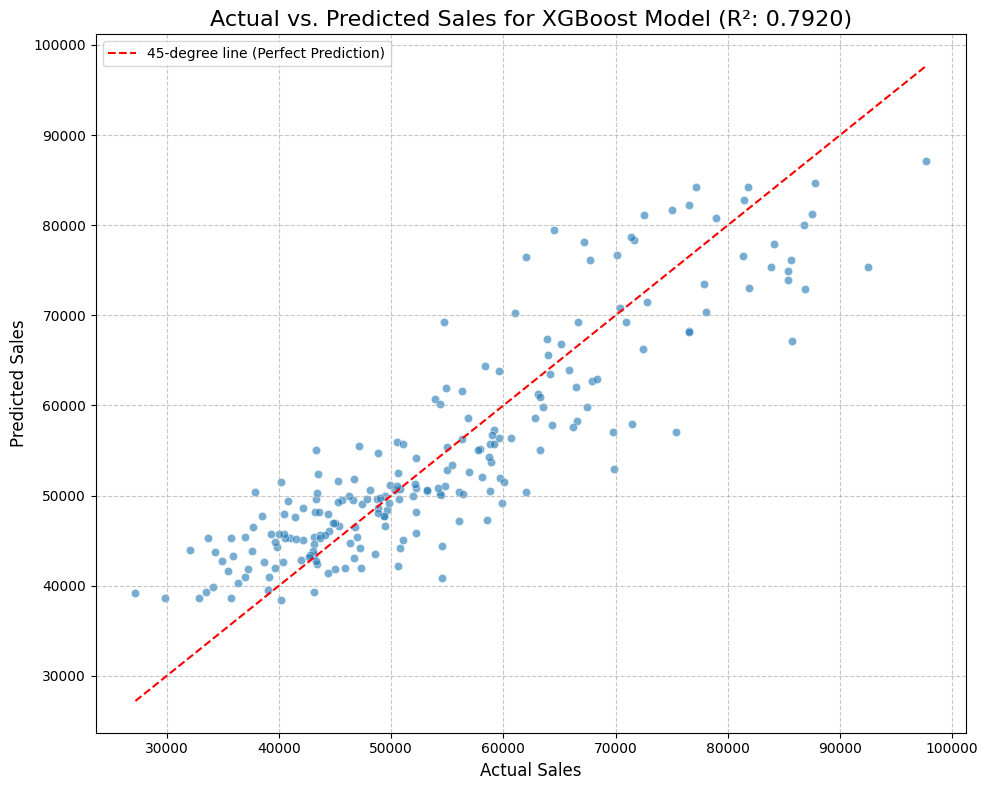

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. Feature Importance (XGBoost Weight) ---

# Get feature importances from the best model (XGBoost)
# Ensure model_to_use is indeed the XGBoost model and it has the feature_importances_ attribute
if best_model_name == "XGBoost":
    feature_importances = model_to_use.feature_importances_
    features_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': feature_importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=features_df, palette='viridis', hue='Feature', legend=False)
    plt.title(f'Feature Importance for {best_model_name} Model', fontsize=16)
    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print(f"Feature importance for {best_model_name} is not directly available via .feature_importances_ or requires a different approach.")

print("\n")

# --- 2. Actual vs. Predicted Scatter Plot for XGBoost ---

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=xgb_preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         '--r', label='45-degree line (Perfect Prediction)')
plt.title(f'Actual vs. Predicted Sales for {best_model_name} Model (R²: {best_model_info["R2 Score"]:.4f})', fontsize=16)
plt.xlabel('Actual Sales', fontsize=12)
plt.ylabel('Predicted Sales', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

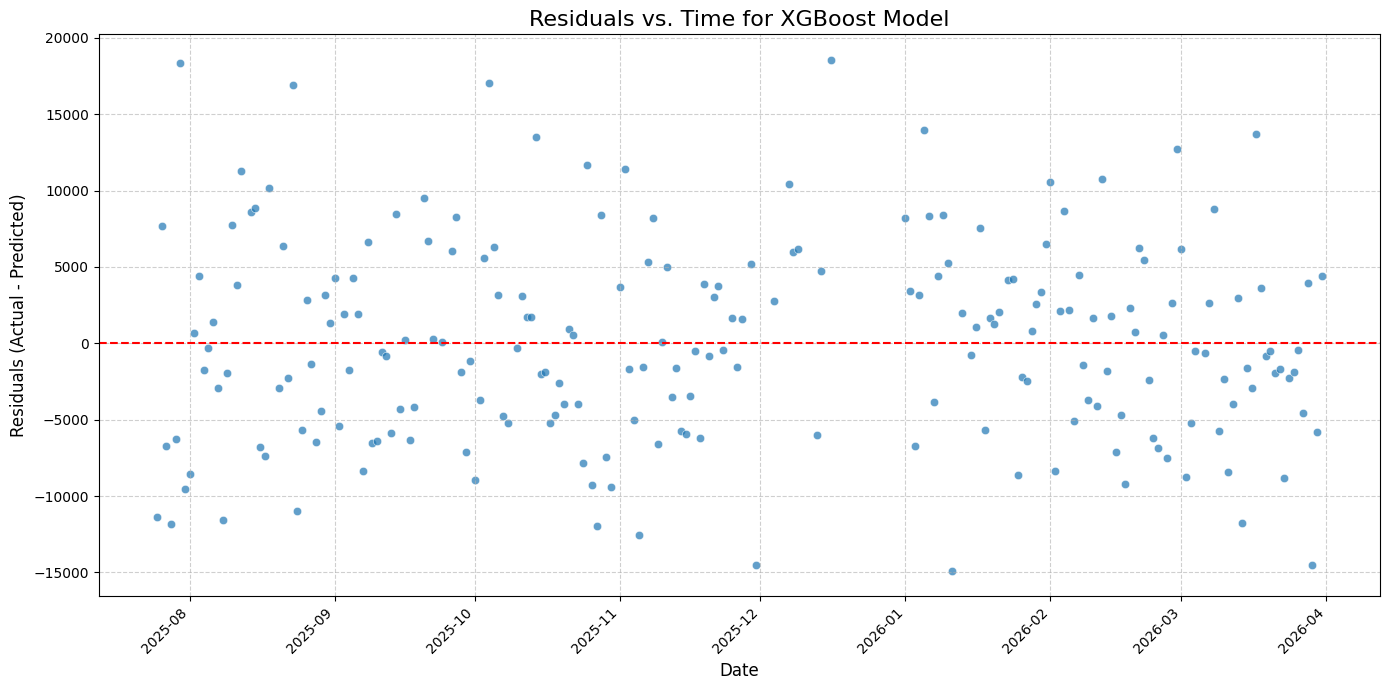

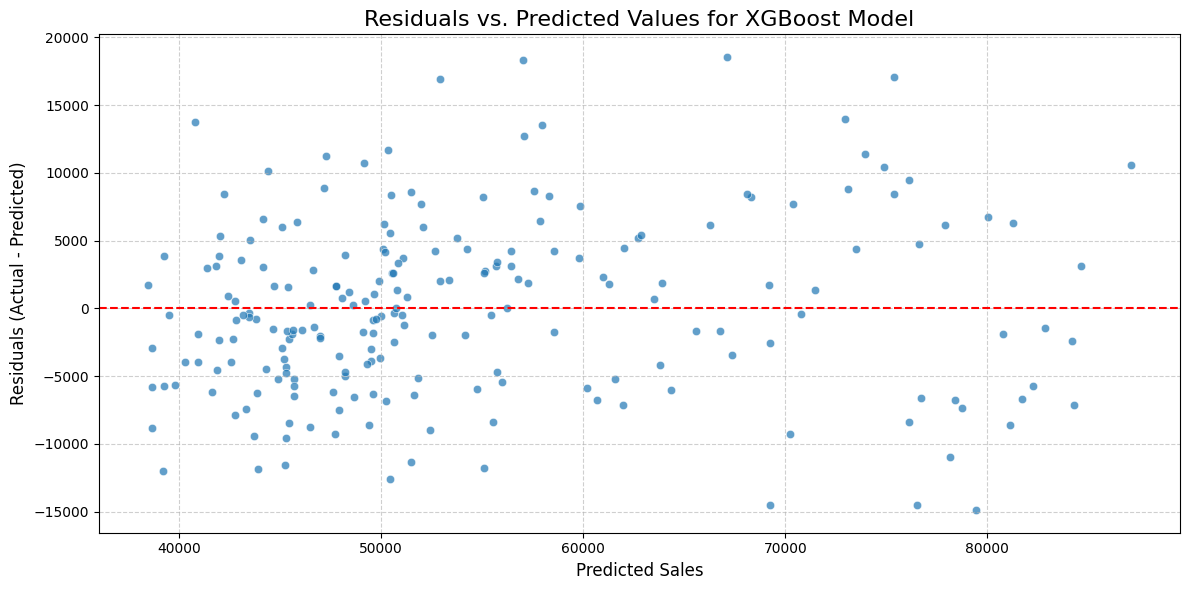

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals for the best model (XGBoost)
residuals_xgb = y_test - xgb_preds

# --- 1. Residuals vs. Time Plot ---

# Get the corresponding dates for the test set
# Assuming X_test's index aligns with daily_sales for Date column
test_dates = daily_sales.loc[y_test.index, 'Date']

plt.figure(figsize=(14, 7))
sns.scatterplot(x=test_dates, y=residuals_xgb, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.title(f'Residuals vs. Time for {best_model_name} Model', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n")

# --- 2. Residuals vs. Predicted Values Plot ---

plt.figure(figsize=(12, 6))
sns.scatterplot(x=xgb_preds, y=residuals_xgb, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.title(f'Residuals vs. Predicted Values for {best_model_name} Model', fontsize=16)
plt.xlabel('Predicted Sales', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()